# 一、前言

给出第一个连续调节模型复杂度的旋钮————把 ‖w‖² 加进损失，逼权重别长太大。这是以后每个训练脚本都会碰到的超参（AdamW 里的 weight_decay 就是它）。

动手目标：跑通从零 + 简洁两版，亲眼看到 lambd=0 → ‖w‖≈13（严重过拟合），lambd=3 → ‖w‖≈0.36（泛化变好）。

# 二、代码

## 1. 造一个"必过拟合"的数据集

In [14]:
%matplotlib inline
# jupyter 魔法命令，绘图内嵌在 notebook 页面，不弹出独立窗口。

import torch
from torch import nn
from d2l import torch as d2l

n_train, n_test, num_inputs, batch_size = 20, 100, 200, 5     # 训练样本 20 个；测试样本 100 个；特征维度 200
true_w, true_b,  = torch.ones((num_inputs, 1)) * 0.01, 0.05
train_data = d2l.synthetic_data(true_w, true_b, n_train)      # 生成线性回归数据集 y = w @ X + b
train_iter = d2l.load_array(train_data, batch_size)
test_data = d2l.synthetic_data(true_w, true_b, n_test)
test_iter = d2l.load_array(test_data, batch_size, is_train = False)
evaluate_loss = d2l.evaluate_loss           # 损失评估函数，用来计算数据集上平均 MSE 损失

n_train=20 但 num_inputs=200：特征数是样本数的 10 倍，模型容量远超数据量，数学上必然过拟合。这是刻意设计的"教学场景"——如果换成 200 个样本，效果就没这么戏剧性，会看不清 λ 的作用。

真实标签 y = 0.05 + Σ 0.01·xᵢ + ε，ε~N(0, 0.01²)：数据本身是线性可完美拟合的，所以 test loss 高只能怪"学歪了"，不能怪"任务太难"。

true_w 形状是 (200,1)，因为 synthetic_data 按矩阵乘法 X@w 生成标签。

d2l.synthetic_data(w,b,n)d2l 内置函数，生成线性回归数据集<br>
输入：真实权重 w、真实偏置 b、样本数量<br>
返回：(features, labels)<br>
features：(n, num_inputs) 高斯随机自变量<br>
labels：\(Xw+b\)，再加上高斯噪声

## 2. 初始化参数（从零版）

In [15]:
def init_params():
    w = torch.normal(0, 1, size = (num_inputs, 1), requires_grad = True)
    b = torch.zeros(1, requires_grad = True)
    return [w, b]

这里用的是裸 tensor + requires_grad=True，不是 nn.Parameter——因为从零版要走手写的 d2l.sgd，不需要 nn.Module 的参数管理。<br>
如果不写 requires_grad=True 的后果：l.backward() 时 w 没有 grad，d2l.sgd 直接崩。<br>
b 初始化为 0 没问题（bias 的梯度会自己学），w 必须随机初始化打破对称性（虽然这里线性回归没有对称性问题，但这是惯例）。

## 3. L2 惩罚项

In [16]:
def l2_penalty(w):
    return torch.sum(w.pow(2)) / 2

向量 L2‑范数（欧几里得范数）<br>
$$\|w\|_2 = \sqrt{\sum_{i=1}^{n} w_i^2}$$

L2惩罚项（L2范数平方 / 代码 l2_penalty 使用）<br>
$$\text{L2‑penalty}(w) = \frac12\|w\|_2^2 = \frac12\sum_{i=1}^{n} w_i^2$$

为什么除以 2：惩罚项 λ/2·‖w‖² 对 w 求导得 λw，2 和 1/2 抵消。不除以 2 也能用，只是更新式里会多个 2。

为什么是平方范数而不是 ‖w‖：平方去掉开根号，导数 = 各项导数的和，好算。而且平方对大分量惩罚更狠。

L1‑范数（1‑范数，曼哈顿范数）<br>
‖W‖1 =Σ |Wi| <br>
正则：Lasso，产生稀疏解。<br>
为什么不是 L1（|w|₁）：L2 惩罚大权重 → 权重倾向于均匀分布在 200 个特征上；L1 会把权重清成稀疏（特征选择）不管权重多大，每一份权重惩罚力度一样（绝对值）。两者都在统计里对应经典模型：岭回归 / Lasso

范数算完最后得到：一个单独的数字（标量），不是列表、不是向量！<br>
输入：向量 / 矩阵（一堆数）<br>
输出：1 个数值，代表这个向量的「长度 / 大小」。

## 4.训练主循环（从零版）

In [17]:
def train(lambd):
    w, b = init_params()
    net, loss = lambda X : d2l.linreg(X, w, b), d2l.squared_loss
    # 匿名函数，线性回归模型：y_hat = X @ w + b;均方误差损失函数，返回每个样本单独损失（向量），形状 [batch_size]
    
    num_epochs, lr = 100, 0.003
    animator = d2l.Animator(xlabel = 'epochs', ylabel = 'loss', yscale = 'log',
                            xlim = [5, num_epochs], legend = ['train', 'test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            # 增加了L2范数惩罚项，
            # 广播机制使l2_penalty(w)成为一个长度为batch_size的向量
            l = loss(net(X), y) + lambd * l2_penalty(w)
            l.sum().backward()
            d2l.sgd([w, b], lr, batch_size)
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss),
                                     evaluate_loss(net, test_iter, loss)))
    print('w的L2范数是:', torch.norm(w).item())
'''
animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss),
                                     evaluate_loss(net, test_iter, loss)))
参数 1：epoch + 1 → X 轴横坐标
横坐标：当前训练轮数。
epoch循环从 0 开始，所以第 0 轮实际是第 1 个 epoch，写epoch+1，图上横坐标就从 1 开始计数。

参数 2：(loss_train, loss_test) → Y 轴上两条曲线的纵坐标
第一个函数：evaluate_loss(net, train_iter, loss) → 训练集损失 y₁
第二个函数：evaluate_loss(net, test_iter, loss) → 测试集损失 y₂

两条曲线一一对应初始化 Animator 时设置的图例：legend = ['train', 'test']
'''

net = lambda X: d2l.linreg(X, w, b)：闭包捕获 w、b，所以从零版不需要 nn.Module。这是"手写版"和"简洁版"的根本区别——参数在哪里、由谁管理。

l = loss(net(X), y) + lambd * l2_penalty(w)：squared_loss 返回形状 (batch_size,) 的逐样本损失，而 l2_penalty 是标量。标量 + 向量 → 广播成 (batch_size,) 向量，每个样本的损失都加了同一个惩罚。

d2l.sgd([w, b], lr, batch_size)：内部做 param -= lr * param.grad / batch_size 并 grad.zero_()。梯度是 batch 内求和，所以除以 batch_size 得到平均。

这节和 Torch-10 的唯一区别就是多了 lambd * l2_penalty(w) 一行——体会一下"框架没变，只动损失"的模块化思维。

## 5.不正则化：看它怎么炸

w的L2范数是: 13.47055721282959


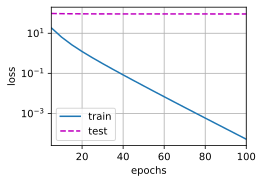

In [18]:
train(lambd = 0)

观察（对照动画曲线 + 打印的范数）：<br>
train loss 一路降到接近 0，test loss 居高不下 → 训练误差减少但测试误差不减少，典型过拟合。<br>
w的L2范数 ≈ 13（每次运行有浮动）：200 个特征、20 个样本，模型把权重学得又大又乱去硬凑训练集。<br>
要点：lambd=0 时惩罚项恒为 0，等价于普通线性回归——这就是对照组。

## 6.开正则化：看它怎么救

w的L2范数是: 0.3985151946544647


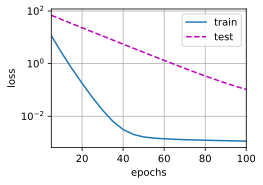

In [27]:
train(lambd = 3)

观察：<br>
train loss 反而变大，但 test loss 变小 → 这正是正则化想要的效果：牺牲一点训练精度，换泛化。<br>
w的L2范数 ≈ 0.36：权重被压到真值（0.01）附近。<br>
要点：λ 是"连续旋钮"——Torch-10 里只能靠换模型阶数（离散选择）调复杂度，这里 λ 从 0 到 3 可以平滑地压容量。λ 越大，(1-ηλ) 缩得越狠，权重越接近 0，模型越简单。

正则化 = 给模型加一条 “约束 / 惩罚规则”，专门用来防止过拟合，提升模型泛化能力。

## 7.简洁实现：框架内置 weight_decay

w 的范数是: 0.3488704264163971


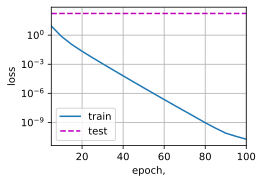

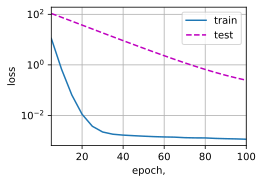

In [26]:
def train_concise(wd):
    net = nn.Sequential(nn.Linear(num_inputs, 1))  # 搭建单层线性网络：输入维度num_inputs=200，输出 1；等价模型 y_hat =Xw+b 。
    for param in net.parameters():
        param.data.normal_()   # 权重、偏置就地用标准正态分布随机初始化。
    loss = nn.MSELoss(reduction = 'none')
    num_epochs, lr = 100, 0.003
    # 偏置参数没有衰减
    trainer = torch.optim.SGD([
        {'params':net[0].weight, 'weight_decay': wd},
        {'params':net[0].bias}], lr = lr)
    animator = d2l.Animator(xlabel = 'epoch,', ylabel = 'loss', yscale = 'log',
                            xlim = [5, num_epochs], legend = ['train','test'])
    for epoch in range(num_epochs):
        for X, y in train_iter:
            trainer.zero_grad()
            l= loss(net(X), y)
            l.mean().backward()
            trainer.step()
        if (epoch + 1) % 5 == 0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss),
                                     evaluate_loss(net, test_iter, loss)))
    print('w 的范数是:', net[0].weight.norm().item())

train_concise(0)
train_concise(3)
'''
trainer = torch.optim.SGD([
        {'params':net[0].weight, 'weight_decay': wd},
        {'params':net[0].bias}], lr = lr)
传给 SGD 的第一个参数是一个列表，列表里面装了 2 个字典。
每一个字典 = 一组参数 + 这一组专属的优化配置

第 1 个字典
'params':net[0].weight：这一组包含的参数是：第一层的权重 w
'weight_decay': wd：给这一组开启权重衰减 (L2 正则)，衰减系数 = wd
权重 w：施加 L2 惩罚

第 2 个字典
'params':net[0].bias：这一组包含的参数是：第一层的偏置 b
字典里面没有写 weight_decay
没有显式设置的参数，weight_decay 默认值 = 0
偏置 b：不施加 L2 惩罚

Sequential 存的元素：一层、一层、一层……，不是权重，不是参数！
net[0]   → 取容器里面的第 0 号元素：第一层 nn.Linear
net[1]   → 如果有第二层，才取第二层
'''

# 三、小结

1.写出带 L2 惩罚的 SGD 更新式，指出哪一项是"衰减"，并解释：为什么 λ 从 0 变到 3，‖w‖ 会从 ≈13 掉到 ≈0.36？<br>
$$w_i \leftarrow w_i(1-\eta\lambda)-\eta\frac{\partial\text{MSE}}{\partial w_i}$$<br>
衰减来源有两处：系数 (1−ηλ)，以及梯度里新增的 λw 项——后者才是主角。
13 → 0.36 的真实机制：<br>
λ=0：目标只有"拟合数据"，没有任何力把权重往 0 拉。20 样本、200 参数是欠定方程组，有无穷多组解，梯度下降会落到"恰好穿过训练点但 w 很大"的那种解，‖w‖ 长到 13。<br>
λ=3：损失多了 λ/2‖w‖²，梯度多出 λw，每步更新额外把 w 拉向 0。注意 ηλ = 0.009，(1−ηλ) 每步只缩 0.9%——光靠这个系数解释不了 97% 的压缩。真正起作用的是梯度项 λw 的持续拉力，最终停在"拟合梯度"和"惩罚梯度"平衡的点（≈0.36）。

2.为什么用平方 L2 范数（‖w‖²/2）而不是 L2 范数 ‖w‖，也不是 L1 范数 |w|₁？从"求导方便"和"对权重分布的影响"两个角度分别说。<br>
| 候选 | 求导 | 对权重分布的影响 |
|---|---|---|
| ‖w‖²/2 | 导数 = w，干净 | 大权重惩罚重 → 权重**均匀压缩**（接近同尺度） |
| ‖w‖ | 导数 = w/‖w‖，**w=0 处不可导**，且尺度不变（w 全乘 2，惩罚不变，不合理） | — |
| \|w\|₁ | 导数 = sign(w)，常数 | 每个权重惩罚恒定 → 小权重被**精确清零** → **稀疏解/特征选择** |

3.Cell 5 里 l = loss(net(X), y) + lambd * l2_penalty(w) 后必须 l.sum().backward()。问：(a) loss 返回什么形状？(b) l2_penalty(w) 是标量，为什么能加到向量上？(c) 直接 l.backward() 会怎样？<br>
a.loss 返回[5,1];y_hat = linreg(X,w,b) = X@w+b，X(5,200) @ w(200,1) 保持列向量形状，squared_loss 形状不变。<br>
b.因为广播，自动把他和前面的形状相匹配；c.l 是 二维向量，而只接受标量，直接那么写会报错

4.简洁实现里为什么要用参数组把 weight 和 bias 分开？PyTorch 默认行为是什么？bias 不衰减的合理性在哪？<br>
因为b 是偏置参数，属于平移量，不用衰减；默认二者是不分开的；bias 不放大输入特征的敏感度，而过拟合的本质是 w 对特征过度敏感，所以惩罚项只针对 w 是合理的。

5.为什么 lambd=0 时 train loss 能降到接近 0，test loss 却很高？结合 n_train=20、num_inputs=200 和"容量"概念回答。<br>
当特征数量，极大的超过训练样本数，那么模型相对于样本就会很复杂，那么训练的越多，对参数就极易记住，产生过拟合现象;<br>
20 个样本、200 个参数，欠定方程组，总存在一组 w 让训练误差精确为 0，甚至能记住训练点的随机噪声 ε。训练归零 ≠ 学到规律，测试点是没见过的，那些"硬凑"的权重在测试点上崩。

6.从贝叶斯 MAP 角度，L2 正则对应什么先验？这解释了"正则化"这个词的什么含义？
L2 惩罚项对应高斯先验（log 后变成 λ‖w‖²）;正则化就是给模型添加一条约束，用来防止过拟合现象,MAP 解 = 似然 × 先验，正则项本质是给参数施加先验偏好，把欠定问题的无穷多解中"不合理的"排除掉，选出先验认为更可能（更小、更平滑）的解。"防止过拟合"只是外在表现，"约束解空间、表达先验偏好"才是本质。

# 附加

L2惩罚作用权重完整推导过程

1. 先写出完整损失公式<br>
$\mathcal{L}_{total} = \text{MSE损失} + \lambda \cdot \frac12\sum_{i=1}^{200} w_i^2$<br>
- MSE：来自样本数据的误差<br>
- $\lambda\cdot\frac12\sum w_i^2$：L2 惩罚项，只跟权重 w 有关，和数据 X、y 毫无关系

2. 对权重 $w_i$ 求偏导（梯度）<br>
$\frac{\partial \mathcal{L}_{total}}{\partial w_i}
=\frac{\partial \text{MSE}}{\partial w_i} + \lambda\,w_i$<br>
 重点来了<br>
 原来不加 L2 的时候梯度只有第一项 $\frac{\partial\text{MSE}}{\partial w_i}$<br>
 加上 L2 惩罚之后，梯度硬生生多出一项：$\lambda w_i$

3. SGD 参数更新公式，学习率 $\eta$<br>
$$w_i \leftarrow w_i - \eta \cdot \frac{\partial\mathcal{L}_{total}}{\partial w_i}$$<br>
$$w_i \leftarrow w_i - \eta\Big(\frac{\partial\text{MSE}}{\partial w_i}+\lambda w_i\Big)$$<br>
$$w_i \leftarrow w_i(1-\eta\lambda)-\eta\frac{\partial\text{MSE}}{\partial w_i}$$<br>
肉眼可见的衰减效果：<br>
$(1-\eta\lambda)$ 一定是一个小于 1 的正数。<br>
每一次更新前，先把旧的权重 $w_i$ 乘上一个 0‑1 之间的系数，权重就被缩小了！<br>
这就叫权重衰减。<br>
举个数字例子：<br>
$\eta=0.003,\lambda=3$<br>
$1-\eta\lambda= 1-0.003\times3= 0.991$<br>
旧权重 $w=10 \rightarrow 10 \times 0.991 = 9.91$，权重被强行压小一点。

4. 偏置 b 为什么不受惩罚？<br>
看梯度公式：惩罚项 $\frac12\sum w_i^2$ 里面根本没有 b<br>
$$\frac{\partial(\text{惩罚项})}{\partial b}=0$$<br>
b 的梯度不会多出额外那一项，所以 b 不会衰减。

5. 对应回到代码一行一行跟踪全过程<br>
l = loss(net(X), y) + lambd * l2_penalty(w)

6. 贝叶斯视角：后验 ∝ 似然 × 先验。L2 惩罚项对应高斯先验（log 后变成 λ‖w‖²），L1 对应拉普拉斯先验。所以正则化 ≈ 给参数一个"别跑太远"的先验信念。